# Resource Estimation of Hamiltonian Simulation of the SYK Model

/tmp/ipykernel_339479/4274048360.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2.0)


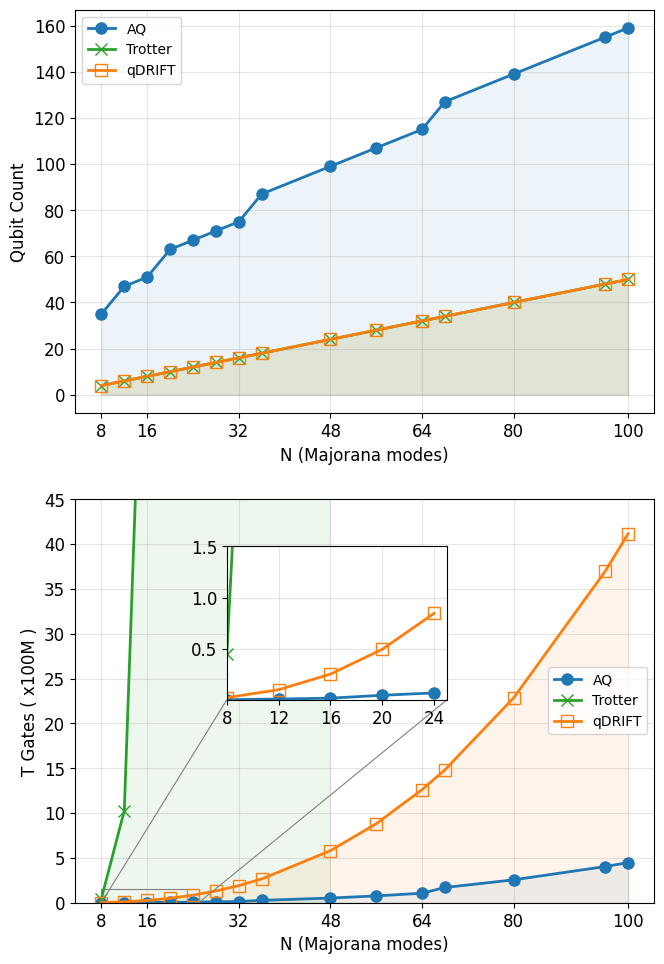

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np
from decimal import Decimal, getcontext
getcontext().prec = 60

export_image_filename = "re_data/N_scaling.pdf"


plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
})

df = pd.read_csv("re_data/scale_N_J1_order1.csv")
df = df[df["N"] <= 100]
colors  = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])
markers = cycle(["o", "s", "^", "D", "v", "P", "X", "*", "h", "+"])

type_styles = {
    type_label: {"color": next(colors), "marker": next(markers)}
    for type_label in df["type"].unique()
}

decorations_by_type = {
    "AQ": dict(color='tab:blue', marker='o'),
    "qDRIFT": dict(color='tab:orange', marker='s', fillstyle='none'),
    "Trotter": dict(color='tab:green', marker='x'),
}

fig, axes = plt.subplots(2, 1, figsize=(7, 10))

rotation_eps = 1e-3

inset_data = {}
for (type_label, epsilon), group in df.groupby(["type", "epsilon"]):
    if epsilon == 0.001:
        continue
    group = group.sort_values("epsilon")
    epsilon_alg = group["epsilon"].values[0]
    style = type_styles[type_label]
    group = group.sort_values("N")
    N_vals          = group["N"].tolist()
    qubit_highwater = group["qubit_highwater"].tolist()
    total_t_gates   = (group["t_gates"]+group['rotations']*(0.53* np.log2(1/(1 - (1-(group['epsilon']))**(1/ (group['rotations'])))) + 4.86)).tolist()

    kwargs = dict(linewidth=2, markersize=8, label=type_label)

    axes[0].plot(N_vals, qubit_highwater, **kwargs, **decorations_by_type[type_label])
    axes[0].fill_between(N_vals, qubit_highwater, alpha=0.08, color=style["color"])

    axes[1].plot(N_vals, total_t_gates, **kwargs, **decorations_by_type[type_label])
    axes[1].fill_between(N_vals, total_t_gates, alpha=0.08, color=style["color"])
    inset_data[type_label] = {"N": N_vals, "tgates": total_t_gates, "style": style}


axes[0].set_xlabel("N (Majorana modes)", fontsize=12)
axes[0].set_ylabel("Qubit Count", fontsize=12)
axes[0].legend()
axes[0].grid(True, color="gray", alpha=0.2)
axes[0].set_xticks([8,16,32,48,64,80,100])
axes[1].set_xlabel("N (Majorana modes)", fontsize=12)
axes[1].set_ylabel("T Gates ( x100M )", fontsize=12)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x/1e8)}")
)
axes[1].set_xticks([8,16,32,48,64,80,100])
axes[1].set_ylim(0, 4500000000)
axes[1].legend()
axes[1].grid(True, color="gray", alpha=0.2)

# --- Inset ---
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

n_zoom = 5  # how many data points to show in inset

axins = inset_axes(axes[1], width="38%", height="38%", loc="upper left",
                   bbox_to_anchor=(0.25, -0.10, 1, 1),
                   bbox_transform=axes[1].transAxes)

all_y = []
for type_label, d in inset_data.items():
    style = d["style"]
    axins.plot(d["N"][:n_zoom], d["tgates"][:n_zoom],
               **decorations_by_type[type_label],
               linewidth=2, markersize=8)
    all_y.extend(d["tgates"][:n_zoom])

# Set zoom window
x1 = min(d["N"][0] for d in inset_data.values())
x2 = max(d["N"][n_zoom - 1] for d in inset_data.values())
y1 = min(all_y) * 0.9
y2 = max(all_y) * 1.1

axins.set_xlim(x1, 25)
axins.set_ylim(y1, 150000000)
axins.set_xticks([8, 12, 16, 20, 24])
axins.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e8:.1f}")
)



axins.tick_params(labelsize=12)
axins.grid(True, color="gray", alpha=0.2)

mark_inset(axes[1], axins, loc1=3, loc2=4, fc="none", ec="0.5", lw=0.8)

plt.tight_layout(pad=2.0)
plt.show()
fig.savefig(export_image_filename, dpi=300, bbox_inches="tight")

<>:71: SyntaxWarning: invalid escape sequence '\e'
<>:71: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_339479/3962767871.py:71: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("$\epsilon_{total}$", fontsize=16)


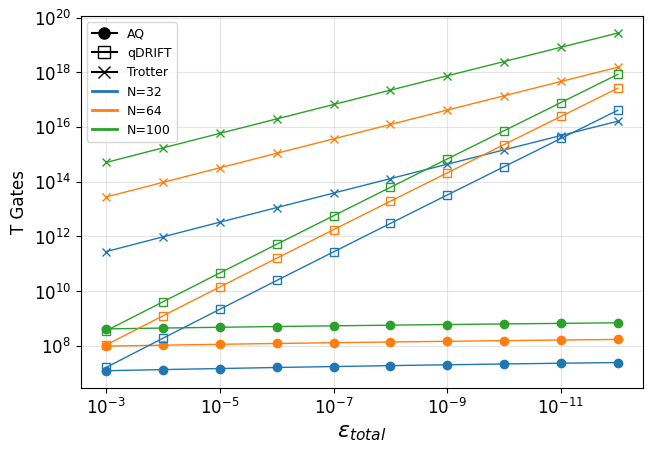

In [2]:
export_image_filename = "re_data/epsilon_scaling.pdf"

df = pd.read_csv("re_data/scale_eps_J1_order1.csv")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 9,
})

fig, ax = plt.subplots(figsize=(7, 5)) 
colors  = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors_by_N = {
    32: 'tab:blue',
    64: 'tab:orange',
    100: 'tab:green',
}
markers_by_type = {
    "AQ": dict(marker='o'),
    "qDRIFT": dict(marker='s', fillstyle='none'),
    "Trotter": dict(marker='x'),
    # "Trotter": dict(linestyle='dashed'),
}

for (type_label, N), group in df.groupby(["type", "N"]):
    if N in [8,16,24,36]:
        continue
    group = group.sort_values("epsilon")

    
    # total_t_gates   = (group["t_gates"]+group['rotations']*(0.53* np.log2(1/(np.expm1(-np.log1p(-group['epsilon'])/group['rotations'])
    total_t_gates   = (group["t_gates"]+group['rotations']* ( np.log2((1 - 1 / -np.expm1(np.log1p(group['epsilon'])/group['rotations'])))*0.53 + 4.86))


    ax.plot(2*group["epsilon"], total_t_gates, color=colors_by_N[N], **markers_by_type[type_label], linewidth=1, markersize=6, label=f"{type_label} N={N}")

type_handles = [
    plt.Line2D([0], [0],
           **markers_by_type[t],
           color="black",
        #    linestyle="",
           markersize=8,
           label=t)
    for t in markers_by_type
]
N_handles = [
    plt.Line2D([0], [0],
           color=colors_by_N[N],
           linewidth=2,
           label=f"N={N}")
    for N in colors_by_N
]
# legend1 = ax.legend(handles=type_handles, title="Algorithm Type", loc="upper left")
# ax.add_artist(legend1)

# legend2 = ax.legend(handles=N_handles, title="System Size N", loc="lower left")

combined_handles = type_handles + N_handles
combined_labels  = [h.get_label() for h in combined_handles]

ax.legend(combined_handles, combined_labels,
          loc="upper left")


ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("$\epsilon_{total}$", fontsize=16)
ax.set_ylabel("T Gates", fontsize=12)
# ax.legend(title="")
ax.grid(True, color="gray", alpha=0.2)

plt.tight_layout(pad=2.0)
plt.show()
fig.savefig(export_image_filename, dpi=300, bbox_inches="tight")